# Анализ текстовых данных

В этом ноутбуке вы научитесь:
1. Очищать текст (приводить к нижнему регистру, удалять знаки препинания)
2. Проводить лемматизацию ( приводить все слова к основе) с помощью pymorphy3
3. Считать частоту слов
4. Удалять стоп-слова
5. Вычислять TF-IDF слов
6. И даже реализуете свой информационный поиск по Вашему корпусу текста

Сгенерируем небольшой набор данных, представляющий собой 5 положительных и 5 отрицательных отзывов на товар.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

import pandas as pd


# Читаем файл построчно и парсим вручную
data = []
with open('spam_utf8.csv', 'r', encoding='utf-8') as f:
    # Пропускаем заголовок
    next(f)

    for line in f:
        # Разделяем ТОЛЬКО по первой запятой
        parts = line.strip().split(',', 1)
        if len(parts) == 2:
            label = parts[0].strip().strip('"')  # убираем кавычки если есть
            text = parts[1].strip().strip('"')   # убираем кавычки если есть
            data.append([label, text])
#df.to_csv('spam_cleaned_utf8.csv', index=False, encoding='utf-8')
# Создаем датафрейм
df = pd.DataFrame(data, columns=['category', 'text'])
# Разделяем датафрейм на ham и spam
df_ham = df[df['category'] == 'ham']
df_spam = df[df['category'] == 'spam']

print(f'\nДо балансировки:')
print(f'Ham: {len(df_ham):,} сообщений')
print(f'Spam: {len(df_spam):,} сообщений')

# Выбираем метод балансировки:
method = 'undersample'  # варианты: 'undersample', 'oversample', 'both'

if method == 'undersample':
    # Метод 1: Уменьшаем ham до размера spam (даунсемплинг)
    df_ham_balanced = resample(df_ham,
                               replace=False,  # без повторений
                               n_samples=len(df_spam),  # до размера spam
                               random_state=42)
    df_balanced = pd.concat([df_ham_balanced, df_spam])

elif method == 'oversample':
    # Метод 2: Увеличиваем spam до размера ham (оверсемплинг)
    df_spam_balanced = resample(df_spam,
                                replace=True,  # с повторениями
                                n_samples=len(df_ham),  # до размера ham
                                random_state=42)
    df_balanced = pd.concat([df_ham, df_spam_balanced])

elif method == 'both':
    # Метод 3: Золотая середина
    target_size = 2000  # целевой размер для каждого класса
    df_ham_balanced = resample(df_ham,
                               replace=False,
                               n_samples=target_size,
                               random_state=42)
    df_spam_balanced = resample(df_spam,
                                replace=True,
                                n_samples=target_size,
                                random_state=42)
    df_balanced = pd.concat([df_ham_balanced, df_spam_balanced])

# Перемешиваем датасет
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nПосле балансировки (метод: {method}):')
print(f'Ham: {len(df_balanced[df_balanced["category"] == "ham"]):,} сообщений')
print(f'Spam: {len(df_balanced[df_balanced["category"] == "spam"]):,} сообщений')
print(f'Всего: {len(df_balanced):,} сообщений')
#df.to_csv('spam_cleaned_and_sort_utf8.csv', index=False, encoding='utf-8')


До балансировки:
Ham: 4,827 сообщений
Spam: 747 сообщений

После балансировки (метод: undersample):
Ham: 747 сообщений
Spam: 747 сообщений
Всего: 1,494 сообщений


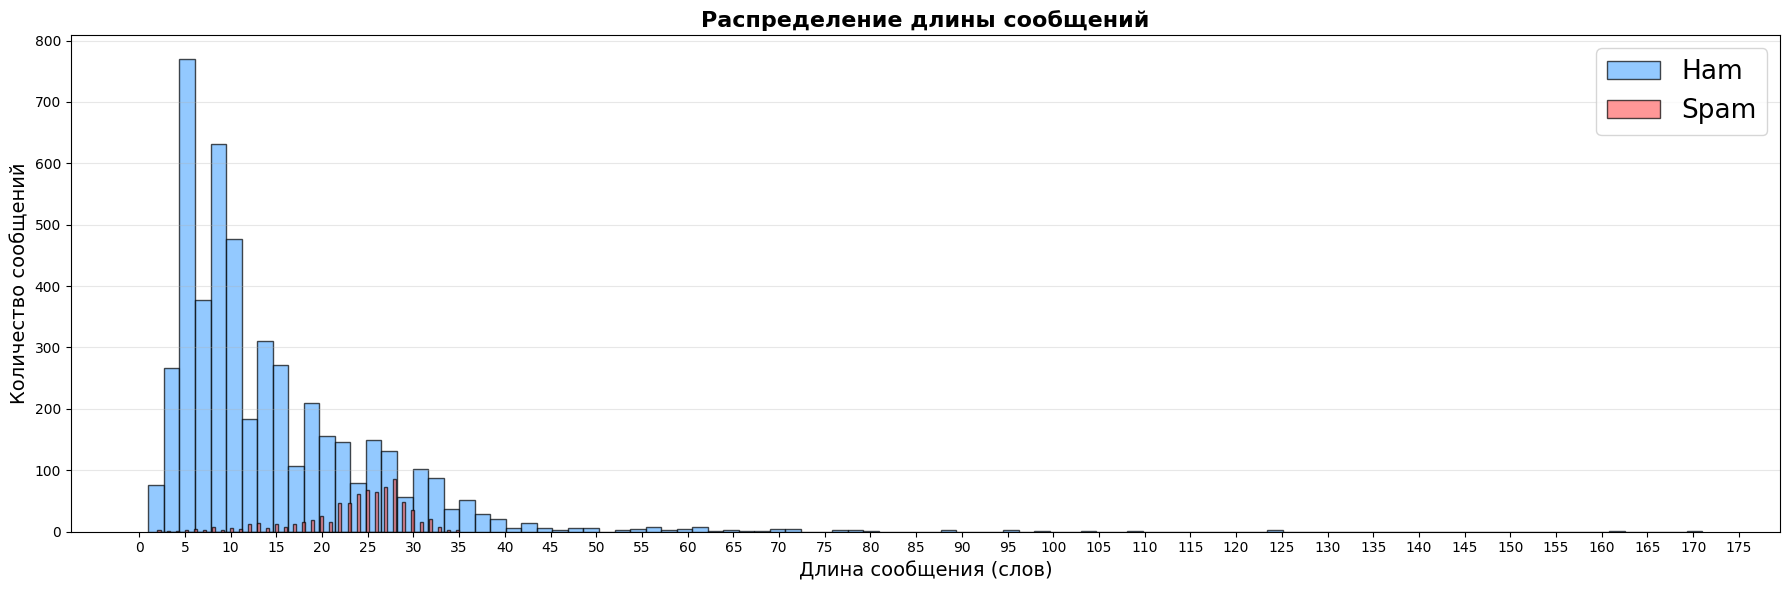

In [42]:
plt.figure(figsize=(18, 6))

plt.hist(ham, bins=100, alpha=0.7, label='Ham', color='#66b3ff', edgecolor='black')
plt.hist(spam, bins=100, alpha=0.7, label='Spam', color='#ff6b6b', edgecolor='black')

plt.xticks(range(0, 176, 5))

plt.xlabel('Длина сообщения (слов)', fontsize=14)
plt.ylabel('Количество сообщений', fontsize=14)
plt.title('Распределение длины сообщений', fontsize=16, weight='bold')
plt.legend(fontsize=19)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

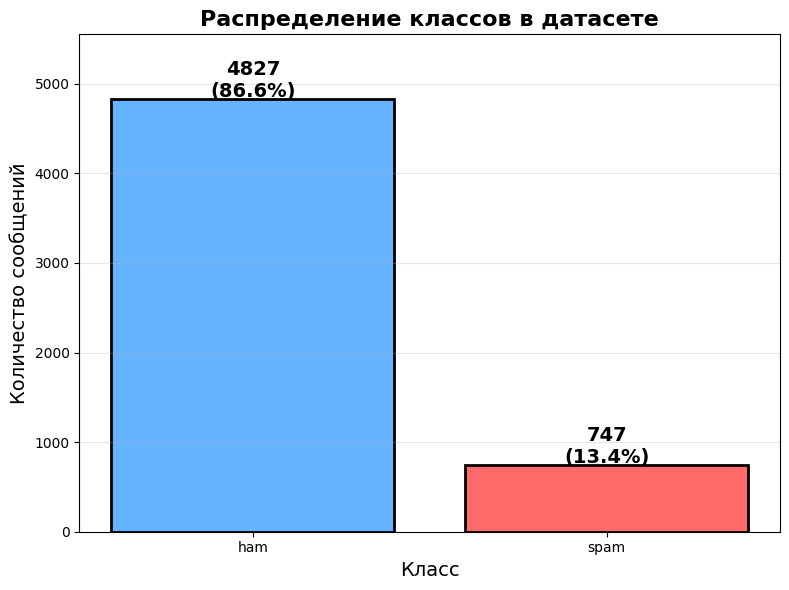

In [44]:
# Считаем количество
counts = df['category'].value_counts()

# Строим гистограмму
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.index, counts.values, color=['#66b3ff', '#ff6b6b'], edgecolor='black', linewidth=2)

# Подписи на столбцах
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=14, weight='bold')

plt.xlabel('Класс', fontsize=14)
plt.ylabel('Количество сообщений', fontsize=14)
plt.title('Распределение классов в датасете', fontsize=16, weight='bold')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

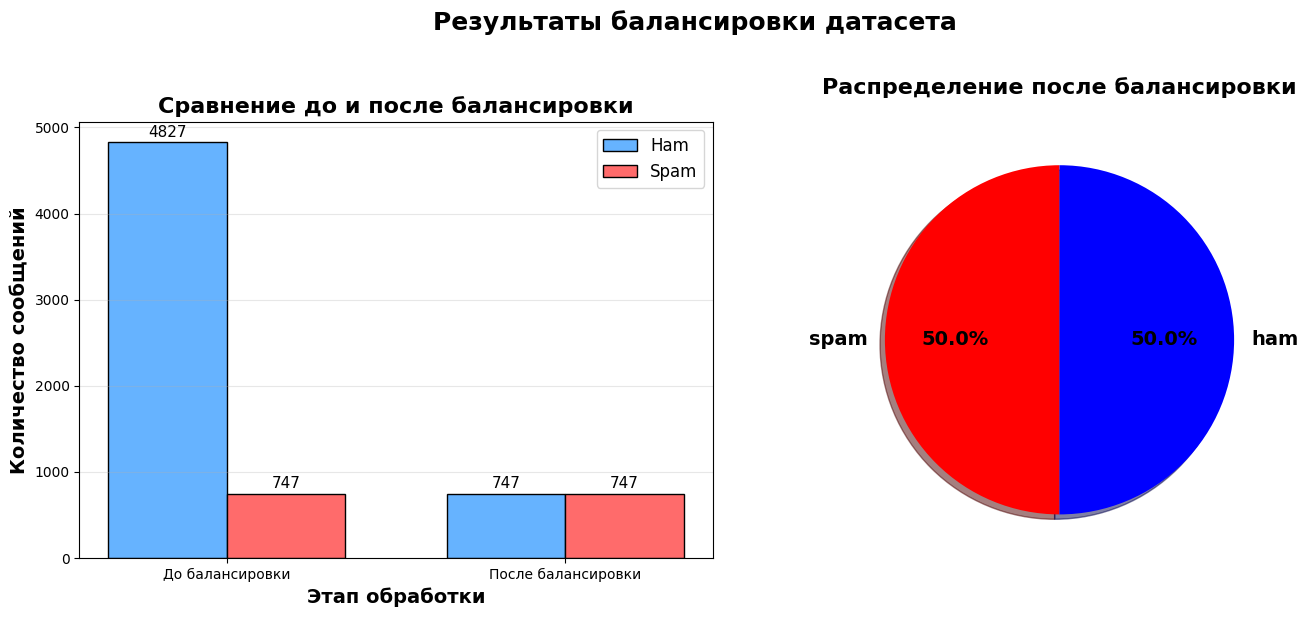

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["red", "blue"]
# График 1: Сравнение до/после
categories = ['До балансировки', 'После балансировки']
ham_counts = [len(df[df['category'] == 'ham']), len(df_balanced[df_balanced['category'] == 'ham'])]
spam_counts = [len(df[df['category'] == 'spam']), len(df_balanced[df_balanced['category'] == 'spam'])]

x = range(len(categories))
width = 0.35

bars1 = axes[0].bar([i - width/2 for i in x], ham_counts, width,
                     label='Ham', color='#66b3ff', edgecolor='black')
bars2 = axes[0].bar([i + width/2 for i in x], spam_counts, width,
                     label='Spam', color='#ff6b6b', edgecolor='black')

axes[0].set_xlabel('Этап обработки', fontsize=14, weight='bold')
axes[0].set_ylabel('Количество сообщений', fontsize=14, weight='bold')
axes[0].set_title('Сравнение до и после балансировки', fontsize=16, weight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend(fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 30,
                     str(height), ha='center', va='bottom', fontsize=11)

# График 2: Круговая диаграмма сбалансированного датасета
balanced_counts = df_balanced['category'].value_counts()
axes[1].pie(balanced_counts.values,
            labels=balanced_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            shadow=True,
            startangle=90,
            textprops={'fontsize': 14, 'weight': 'bold'})
axes[1].set_title('Распределение после балансировки',
                  fontsize=16, weight='bold', pad=20)

fig.suptitle('Результаты балансировки датасета',
             fontsize=18, weight='bold', y=1.02)
plt.tight_layout()
plt.show()
df = df_balanced

In [46]:


print(df.head(10))

  category                                               text
0     spam  URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...
1     spam  Panasonic & BluetoothHdset FREE. Nokia FREE. M...
2     spam  Do you want a new Video handset? 750 any time ...
3     spam  Hi if ur lookin 4 saucy daytime fun wiv busty ...
4     spam  09066362231 URGENT! Your mobile No 07xxxxxxxxx...
5      ham     When you are big..| God will bring success.,,,
6      ham                         K..give back my thanks.,,,
7      ham  Pls give her prometazine syrup. 5mls then  &lt...
8      ham            How long does applebees fucking take,,,
9      ham  Yup... Ok i go home look at the timings then i...


## 1. Очистка текста

Прежде всего "очистим" текст.

Компьютер воспринимает `"СУПЕР"`, `"Супер"` и `"супер"` как три разных слова.  Чтобы это исправить, приводим все слова к нижнему регистру.

Также удалим знаки препинания (восклицательные знаки, запятые и т.д.), т.е. они не несут смысла.

Для этого используем регулярные выражения (`re.sub`).

In [47]:
import re

def clean_text(text):
    text = text.lower()                    # Всё в нижний регистр
    text = re.sub(r'[^a-z ]', '', text)   # Удаляем всё, кроме русских букв и пробелов
    text = ' '.join(text.split())          # Убираем лишние пробелы
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Покажем, как изменился текст
print(f"До:  {df['text'].iloc[0]}")
print(f"После: {df['clean_text'].iloc[0]}")
print(f"До:  {df['text'].iloc[1]}")
print(f"После: {df['clean_text'].iloc[1]}")
print(f"До:  {df['text'].iloc[2]}")
print(f"После: {df['clean_text'].iloc[2]}")

До:  URGENT, IMPORTANT INFORMATION FOR O2 USER. TODAY IS YOUR LUCKY DAY! 2 FIND OUT WHY LOG ONTO HTTP://WWW.URAWINNER.COM THERE IS A FANTASTIC SURPRISE AWAITING FOR YOU",,,
После: urgent important information for o user today is your lucky day find out why log onto httpwwwurawinnercom there is a fantastic surprise awaiting for you
До:  Panasonic & BluetoothHdset FREE. Nokia FREE. Motorola FREE & DoubleMins & DoubleTxt on Orange contract. Call MobileUpd8 on 08000839402 or call 2optout,,,
После: panasonic bluetoothhdset free nokia free motorola free doublemins doubletxt on orange contract call mobileupd on or call optout
До:  Do you want a new Video handset? 750 any time any network mins? UNLIMITED TEXT? Camcorder? Reply or Call now 08000930705 for del Sat AM,,,
После: do you want a new video handset any time any network mins unlimited text camcorder reply or call now for del sat am


## 2. Лемматизация (приведение слов к начальной форме)

Слова `"заказывать"`, `"заказываю"`, `"заказал"` — для компьютера это разные слова, но для человека это одно и то же.

**Лемматизация** приводит слова к их начальной форме:
- `"заказывать"`, `"заказываю"` → `"заказывать"`
- `"товары"`, `"товаром"` → `"товар"`
- `"лучше"`, `"лучший"` → `"лучший"`

Для русского языка используем библиотеку `pymorphy3` — морфологический анализатор для русского языка. Она умеет определять часть речи, число, падеж и начальную форму слова.
Для английского языка - nltk.

In [ ]:
# Установка библиотеки (раскомментируйте и запустите один! раз)
#python -m spacy download en_core_web_sm

далее идет пример для spacy

In [8]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp("This is the best day ever")

for token in doc:
    print(f"Слово: {token.text} → Лемма: {token.lemma_}")

Слово: This → Лемма: this
Слово: is → Лемма: be
Слово: the → Лемма: the
Слово: best → Лемма: good
Слово: day → Лемма: day
Слово: ever → Лемма: ever


и сама реализация лемматизации для ангийского языка

In [48]:
def lemmatize_text_spacy(text):
    """
    Приводит текст к начальным формам слов с помощью spaCy.
    """
    if not isinstance(text, str):
        return ""
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    return ' '.join(lemmas)

# Применяем функцию ко всем текстам в датасете
df['lemmas'] = df['clean_text'].apply(lemmatize_text_spacy)

# Проверка результата
print("Пример лемматизации:")
print(f"Исходный текст: {df['clean_text'].iloc[0]}")
print(f"Лемматизированный: {df['lemmas'].iloc[0]}")
print(f"Исходный текст: {df['clean_text'].iloc[1]}")
print(f"Лемматизированный: {df['lemmas'].iloc[1]}")
print(f"Исходный текст: {df['clean_text'].iloc[2]}")
print(f"Лемматизированный: {df['lemmas'].iloc[2]}")

Пример лемматизации:
Исходный текст: urgent important information for o user today is your lucky day find out why log onto httpwwwurawinnercom there is a fantastic surprise awaiting for you
Лемматизированный: urgent important information for o user today be your lucky day find out why log onto httpwwwurawinnercom there be a fantastic surprise await for you
Исходный текст: panasonic bluetoothhdset free nokia free motorola free doublemins doubletxt on orange contract call mobileupd on or call optout
Лемматизированный: panasonic bluetoothhdset free nokia free motorola free doublemin doubletxt on orange contract call mobileupd on or call optout
Исходный текст: do you want a new video handset any time any network mins unlimited text camcorder reply or call now for del sat am
Лемматизированный: do you want a new video handset any time any network min unlimited text camcorder reply or call now for del sit be


In [49]:
import re

def clean_text(text):
    text = text.lower()                    # Всё в нижний регистр
    text = re.sub(r'[^a-z ]', '', text)   # Удаляем всё, кроме русских букв и пробелов
    text = ' '.join(text.split())          # Убираем лишние пробелы
    return text

df['lemmas_clean'] = df['lemmas'].apply(clean_text)

# Покажем, как изменился текст
print(f"До:  {df['text'].iloc[0]}")
print(f"После: {df['lemmas_clean'].iloc[0]}")

До:  URGENT, IMPORTANT INFORMATION FOR O2 USER. TODAY IS YOUR LUCKY DAY! 2 FIND OUT WHY LOG ONTO HTTP://WWW.URAWINNER.COM THERE IS A FANTASTIC SURPRISE AWAITING FOR YOU",,,
После: urgent important information for o user today be your lucky day find out why log onto httpwwwurawinnercom there be a fantastic surprise await for you


In [55]:
print(f"До:  {df['text'].iloc[1]}")
print(f"После: {df['lemmas_clean'].iloc[1]}")
print(f"Метка: {df['category'].iloc[1]}")
print(f"До:  {df['text'].iloc[2]}")
print(f"После: {df['lemmas_clean'].iloc[2]}")
print(f"Метка: {df['category'].iloc[2]}")
print(f"До:  {df['text'].iloc[127]}")
print(f"После: {df['lemmas_clean'].iloc[127]}")
print(f"Метка: {df['category'].iloc[127]}")

До:  Panasonic & BluetoothHdset FREE. Nokia FREE. Motorola FREE & DoubleMins & DoubleTxt on Orange contract. Call MobileUpd8 on 08000839402 or call 2optout,,,
После: panasonic bluetoothhdset free nokia free motorola free doublemin doubletxt on orange contract call mobileupd on or call optout
Метка: spam
До:  Do you want a new Video handset? 750 any time any network mins? UNLIMITED TEXT? Camcorder? Reply or Call now 08000930705 for del Sat AM,,,
После: do you want a new video handset any time any network min unlimited text camcorder reply or call now for del sit be
Метка: spam
До:  No message..no responce..what happend?,,,
После: no messageno responcewhat happend
Метка: ham


Выведем таблицу с исходным текстом, после очистки, после лемматизации. Проанализируйте, как менялся текст на каждом этапе.

In [50]:
df.head(10)

,category,text,clean_text,lemmas,lemmas_clean
0,spam,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",urgent important information for o user today ...,urgent important information for o user today ...,urgent important information for o user today ...
1,spam,Panasonic & BluetoothHdset FREE. Nokia FREE. M...,panasonic bluetoothhdset free nokia free motor...,panasonic bluetoothhdset free nokia free motor...,panasonic bluetoothhdset free nokia free motor...
2,spam,Do you want a new Video handset? 750 any time ...,do you want a new video handset any time any n...,do you want a new video handset any time any n...,do you want a new video handset any time any n...
3,spam,Hi if ur lookin 4 saucy daytime fun wiv busty ...,hi if ur lookin saucy daytime fun wiv busty ma...,hi if ur lookin saucy daytime fun wiv busty ma...,hi if ur lookin saucy daytime fun wiv busty ma...
4,spam,09066362231 URGENT! Your mobile No 07xxxxxxxxx...,urgent your mobile no xxxxxxxxx won a bonus ca...,urgent your mobile no xxxxxxxxx win a bonus ca...,urgent your mobile no xxxxxxxxx win a bonus ca...
5,ham,"When you are big..| God will bring success.,,,",when you are big god will bring success,when you be big god will bring success,when you be big god will bring success
6,ham,"K..give back my thanks.,,,",kgive back my thanks,kgive back my thank,kgive back my thank
7,ham,Pls give her prometazine syrup. 5mls then &lt...,pls give her prometazine syrup mls then ltgt m...,pls give her prometazine syrup mls then ltgt m...,pls give her prometazine syrup mls then ltgt m...
8,ham,"How long does applebees fucking take,,,",how long does applebees fucking take,how long do applebee fuck take,how long do applebee fuck take
9,ham,Yup... Ok i go home look at the timings then i...,yup ok i go home look at the timings then i ms...,yup ok I go home look at the timing then I msg...,yup ok i go home look at the timing then i msg...


## 3. Подсчёт частоты слов

Посмотрим, какие слова встречаются в наших отзывах чаще всего.
Для этого:


*   Объединим все лемматизированные тексты в один список слов
*   Посчитаем частоту каждого слова с помощью Counter
*   Выведем топ-10 самых частых слов

In [12]:
from collections import Counter

# Объединяем все леммы в один список слов
all_words = ' '.join(df['lemmas_clean']).split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

print("Топ-15 самых частых слов:")
for word, count in word_counts.most_common(15):
    print(f"{word}: {count}")

Топ-15 самых частых слов:
to: 950
be: 668
i: 644
you: 595
a: 530
call: 415
the: 374
your: 329
u: 305
have: 298
for: 280
and: 258
now: 235
free: 226
not: 220


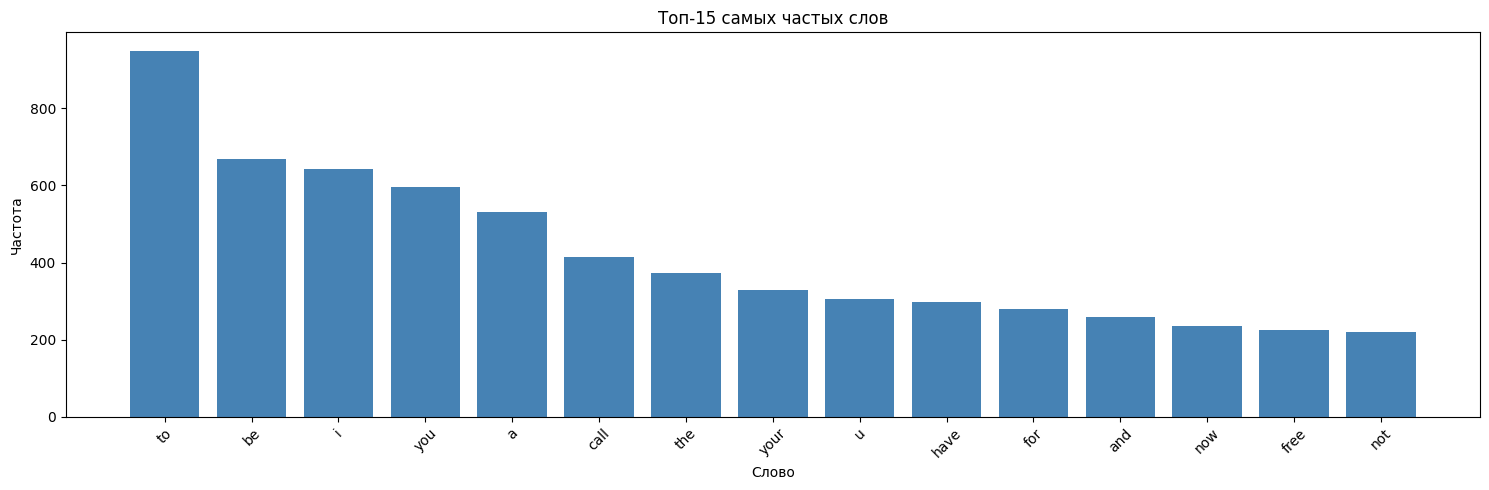

In [13]:
# Строим столбчатый график топ-10 слов
import matplotlib.pyplot as plt

# Берём топ-10 и разделяем на слова и частоты
top_words = word_counts.most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(15, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Топ-15 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Интересную возможность для визуализации дает **облако слов (Word Cloud)** —  способ наглядно показать, какие слова встречаются чаще всего.
**Чем чаще слово**, тем оно **крупнее** на картинке.

Облако слов помогает быстро увидеть:
- Основные темы в текстах
- Какие слова доминируют
- Различия между категориями (если строить отдельно для каждой)

**Параметр `max_words=10`** показывает только топ-10 самых частых слов, чтобы не перегружать картинку. Попробуйте убрать его и построить все слова, будет очень красиво.

In [ ]:
# Установка (один раз)
#!pip install wordcloud

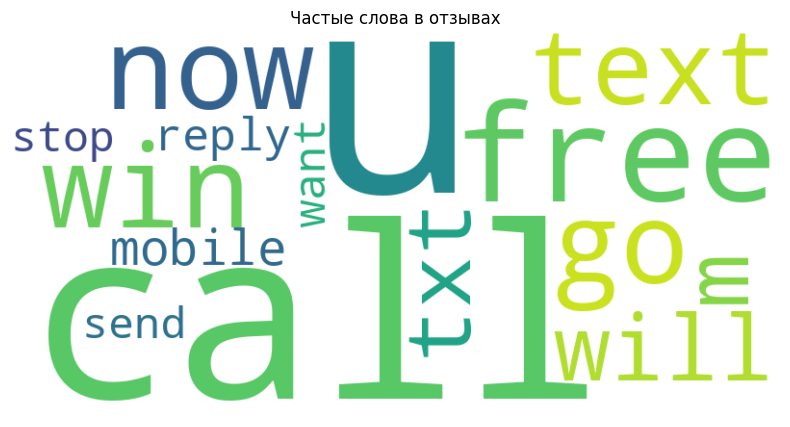

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создаём облако слов
all_text = ' '.join(df['lemmas_clean'])
wc = WordCloud(width=800, height=400,max_words=15,   background_color='white').generate(all_text)

# Показываем
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в отзывах')
plt.show()

Можно построить облака слов для наших категорий - позитивных и негативных отзывов.

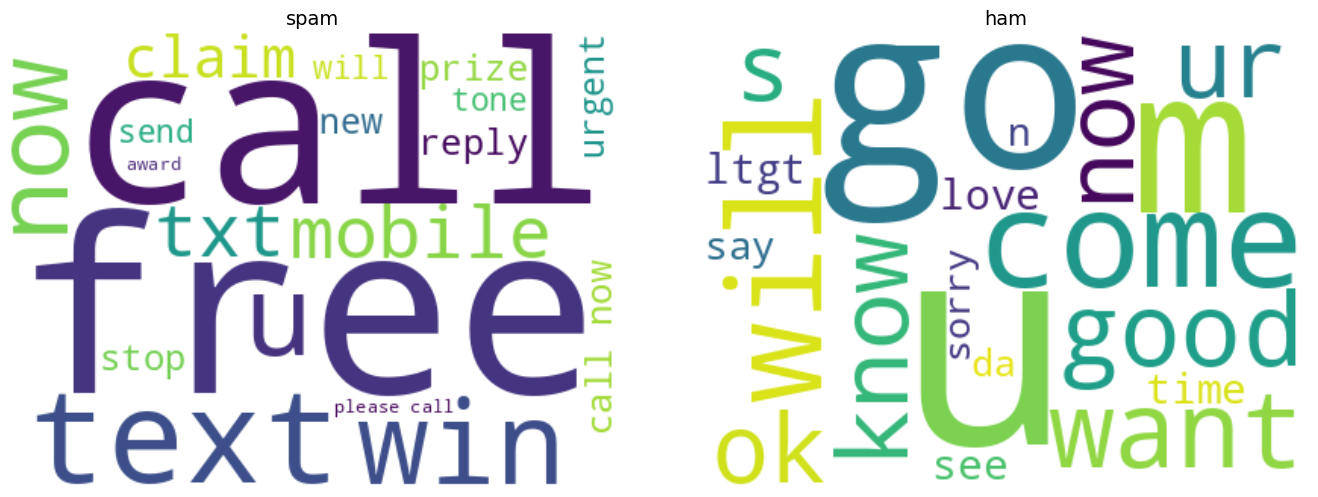

In [15]:
# Облако слов для "Позитива"

pos_text = ' '.join(df[df['category'] == 'spam']['lemmas_clean'])
wc_pos = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(pos_text)

# Облако слов для "Негатива"
neg_text = ' '.join(df[df['category'] == 'ham']['lemmas_clean'])
wc_neg = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('spam', fontsize=14)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('ham', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Удаление стоп-слов

Как мы видим, самым частым словом у нас оказалось "не".
Слова "не", "и", "в", "на" и т.д. встречаются почти в любом тексте, но не несут полезного смысла для анализа.
Такие слова называют стоп-словами и обычно перед анализом текста их удаляют.
Возьмём готовый список русских стоп-слов из библиотеки nltk.

In [16]:
import nltk
from nltk.corpus import stopwords

# Скачиваем список стоп-слов
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
stop_words = set(stopwords.words('english'))         # загружаем русские стоп-слова

print("Примеры стоп-слов:", list(stop_words)[:20])   # первые 20 стоп-слов

# удаляем стоп-слова из наших лемматизированных текстов
def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['no_stopwords'] = df['lemmas_clean'].apply(lambda x: remove_stopwords(x, stop_words))

Примеры стоп-слов: ['will', "he'll", 'mustn', 'of', "we're", 'your', 'ain', "haven't", "weren't", "we'd", "they'd", 're', 'yours', 'been', "mustn't", "mightn't", 'some', 'isn', "they're", 'to']


Вновь проанализируйте, как изменился текст после удаления стоп-слов.

In [18]:
df.head(15)

,category,text,clean_text,lemmas,lemmas_clean,no_stopwords
0,spam,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",urgent important information for o user today ...,urgent important information for o user today ...,urgent important information for o user today ...,urgent important information user today lucky ...
1,spam,Panasonic & BluetoothHdset FREE. Nokia FREE. M...,panasonic bluetoothhdset free nokia free motor...,panasonic bluetoothhdset free nokia free motor...,panasonic bluetoothhdset free nokia free motor...,panasonic bluetoothhdset free nokia free motor...
2,spam,Do you want a new Video handset? 750 any time ...,do you want a new video handset any time any n...,do you want a new video handset any time any n...,do you want a new video handset any time any n...,want new video handset time network min unlimi...
3,spam,Hi if ur lookin 4 saucy daytime fun wiv busty ...,hi if ur lookin saucy daytime fun wiv busty ma...,hi if ur lookin saucy daytime fun wiv busty ma...,hi if ur lookin saucy daytime fun wiv busty ma...,hi ur lookin saucy daytime fun wiv busty marri...
4,spam,09066362231 URGENT! Your mobile No 07xxxxxxxxx...,urgent your mobile no xxxxxxxxx won a bonus ca...,urgent your mobile no xxxxxxxxx win a bonus ca...,urgent your mobile no xxxxxxxxx win a bonus ca...,urgent mobile xxxxxxxxx win bonus caller prize...
5,ham,"When you are big..| God will bring success.,,,",when you are big god will bring success,when you be big god will bring success,when you be big god will bring success,big god bring success
6,ham,"K..give back my thanks.,,,",kgive back my thanks,kgive back my thank,kgive back my thank,kgive back thank
7,ham,Pls give her prometazine syrup. 5mls then &lt...,pls give her prometazine syrup mls then ltgt m...,pls give her prometazine syrup mls then ltgt m...,pls give her prometazine syrup mls then ltgt m...,pls give prometazine syrup mls ltgt min later ...
8,ham,"How long does applebees fucking take,,,",how long does applebees fucking take,how long do applebee fuck take,how long do applebee fuck take,long applebee fuck take
9,ham,Yup... Ok i go home look at the timings then i...,yup ok i go home look at the timings then i ms...,yup ok I go home look at the timing then I msg...,yup ok i go home look at the timing then i msg...,yup ok go home look timing msg xuhui go learn ...


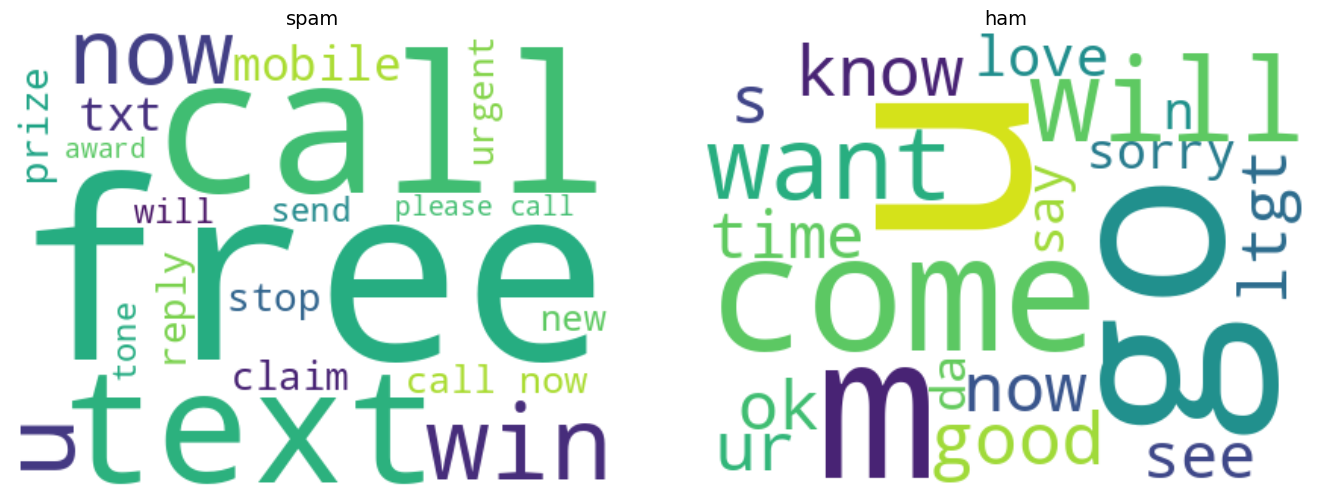

In [19]:
# Облако слов для "Позитива"

pos_text = ' '.join(df[df['category'] == 'spam']['lemmas_clean'])
wc_pos = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(pos_text)

# Облако слов для "Негатива"
neg_text = ' '.join(df[df['category'] == 'ham']['lemmas_clean'])
wc_neg = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('spam', fontsize=14)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('ham', fontsize=14)

plt.tight_layout()
plt.show()

## 5. TF-IDF: превращаем текст в числа

Компьютер не работает со словами — только с числами. Поэтому каждый текст нужно представить в виде вектора чисел. Мы воспользуемя векторайзером TfidfVectorizer, который для каждого слова вычислит "вес" TF-IDF.

Подробно о векторизации текста Вы узнает в ходе дальнейшего обучения, пока нам можно считать, что TF-IDF состоит из TF (Term Frequency), которая показывает как часто слово встречается в этом тексте и IDF (Inverse Document Frequency), которая показывает, насколько редким является слово во всем наборе данных.

Высокий вес **TF-IDF = TF × IDF**  получается, когда слово часто встречается в *этом* отзыве и редко встречается в *остальных* отзывах.  


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# создаём и обучаем векторайзер
vectorizer = TfidfVectorizer(stop_words=list(stop_words))  # обычно именно тут удаляют стоп-слова, а не ранее, как это сделали мы
tfidf_matrix = vectorizer.fit_transform(df['no_stopwords'])

# получаем список всех слов (словарь)
feature_names = vectorizer.get_feature_names_out()
print(f"Размер словаря: {len(feature_names)} слов")

Размер словаря: 3376 слов


Мы собрали все слова из всех текстов в длинный список, у нас получилось 37 слов. Вот так выглядит сам словарь.

In [21]:
feature_names[0:100]

array(['ab', 'abeg', 'aberdeen', 'abi', 'abiola', 'abj', 'able', 'abroad',
       'absolutely', 'abt', 'abta', 'aburo', 'abuse', 'abuser', 'ac',
       'accept', 'access', 'accessible', 'accident', 'accidentally',
       'accommodation', 'accommodationvoucher', 'accomodation',
       'accordingly', 'accordinglyor', 'account', 'aclpm', 'acoentry',
       'acsmsreward', 'act', 'actin', 'action', 'activ', 'activate',
       'active', 'activity', 'actual', 'actually', 'acwicmbcktzr', 'ad',
       'adam', 'add', 'addamsfa', 'address', 'addressull', 'adjustable',
       'admirer', 'adp', 'adrian', 'adrink', 'adsense', 'adult',
       'advance', 'advise', 'advisor', 'ae', 'affair', 'affection',
       'affectionate', 'affidavit', 'afraid', 'african', 'afternoon',
       'ag', 'age', 'agent', 'ageppermesssubscription', 'ago', 'agree',
       'agreen', 'ah', 'aha', 'ahead', 'ahmad', 'aight', 'airport',
       'aiya', 'aiyah', 'aiyar', 'aiyo', 'aj', 'ajith', 'akonlonely',
       'al', 'aldrine',

Теперь каждый текст в нашем наборе данных представляет собой вектор длины 37, значения элементов которого есть TF-IDF слов словаря. Ниже приведен пример первого текста из 5 слов. Соответствующий ему вектор длины 37 содержит ровно 5 ненулевых элементов со значениями TF-IDF этих слов. Если слова нет в тексте, его TF-IDF равен нулю.


In [22]:
# наш первый отзыв в виде вектора
print(f"Текст: {df['no_stopwords'].iloc[0]}")
print(f"Вектор:\n{tfidf_matrix[0].toarray()}")

Текст: urgent important information user today lucky day find log onto httpwwwurawinnercom fantastic surprise await
Вектор:
[[0. 0. 0. ... 0. 0. 0.]]


Теперь тексты можно сравнивать, искать, классифицировать и т.д.

## 6. Информационный поиск

Найдем тексты, которые **наиболее похожи** на поисковый запрос или, другими словами, найдем вектора наших текстов **наиболее похожие** на вектор запроса.

Для измерения похожести векторов обычно используется **косинусное сходство** (cosine similarity), которое равно **1**, если векторы одинаковые.
Подробнее об этой метрике и других Вы также узнаете в ходе дальнейшего обучения.

Реализуем простой поиск.

In [23]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# функция поиска наиболее близких текстов к запросу
def search_texts(query, vectorizer, tfidf_matrix, texts, top_n=3):
    """
    Ищет top_n текстов, наиболее похожих на запрос.
    """
    query = clean_text(query)            # очищаем запрос
    query = lemmatize_text(query)        # лемматизируем запрос
    query_vec = vectorizer.transform([query])  # векторизуем запрос

    # считаем похожесть запроса со всеми текстами
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    # находим индексы топ-n самых похожих
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'Текст': texts.iloc[idx],
            'Похожесть': similarities[idx]
        })

    return results

Приведем пример использования функции поиска. Предположим пользователь вводит в строке поиска "Качество товара".
Найдем текст в нашем наборе данных наиболее близкий к данному запросу.

In [24]:
query = "winner"
# Получаем вектор для запроса
query_vec = vectorizer.transform([query])
# Считаем косинусную похожесть со всеми документами
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
# Создаём DataFrame со всеми сообщениями и их похожестью
all_results = pd.DataFrame({
    'text': df['no_stopwords'],
    'predicted': similarities
})
all_results.to_csv('search_results.csv', index=False)
# Сортируем по убыванию похожести (от самого похожего)
all_results = all_results.sort_values('predicted', ascending=False)
print(f"Сообщение: '{query}'")
print(f"\nВсего сообщений: {len(all_results)}")
print(f"\nВсе сообщения, отсортированные по похожести:\n")
for i, row in all_results.head(20).iterrows():
    print(f"Похожесть: {row['predicted']:.8f}")
    print(f"Текст: {row['text']}")
    print("-" * 80)

Сообщение: 'winner'

Всего сообщений: 1494

Все сообщения, отсортированные по похожести:

Похожесть: 0.35694079
Текст: congratulation win winner august prize draw call prize code
--------------------------------------------------------------------------------
Похожесть: 0.34811665
Текст: winner guarantee caller prize final attempt contact claim call ppmpoboxbhambxe
--------------------------------------------------------------------------------
Похожесть: 0.31066055
Текст: winner specially select receive cash award speak live operator claim call ampm cost p
--------------------------------------------------------------------------------
Похожесть: 0.31066055
Текст: winner specially select receive cash award speak live operator claim call ampm cost p
--------------------------------------------------------------------------------
Похожесть: 0.30199789
Текст: winner u specially select receive cash holiday flight inc speak live operator claim
----------------------------------------------

In [25]:
import pandas as pd

# ==================================================
# 1. ЗАГРУЗИТЕ ДВА ФАЙЛА
# ==================================================

# Файл с ПРЕДСКАЗАНИЯМИ модели (результаты работы модели)
df_pred = pd.read_csv('search_results.csv', encoding='utf-8')

# Файл с ИСТИННЫМИ метками (оригинальный датасет)
df_true = pd.read_csv('spam_utf8.csv', encoding='utf-8')
df_true = df_true[['v1', 'v2']]
df_true.columns = ['true_label', 'text']

# ==================================================
# 2. ОБЪЕДИНЯЕМ ПО ИНДЕКСУ (ПОРЯДКУ СТРОК)
# ==================================================

# Предполагаем, что порядок строк в обоих файлах одинаковый
comparison = pd.DataFrame({
    'true_label': df_true['true_label'],
    'predicted_label': df_pred['predicted'],
    'text': df_true['text']
})
comparison.to_csv('comparison_results.csv', index=False, encoding='utf-8')

In [43]:
df.to_csv('spam_result.csv', index=False, encoding='utf-8')

Проанализируйте полученный результат. Первыми были выведены те тексты, которые содержали оба слова из запроса. Какая похожесть у этих текстов? Что можно сказать о третьем тексте?

# Задание

**Найти текстовый набор данных**, в соответствии с файлом инструкцией, в котором изложены требования.


Примените все 6 шагов из учебного ноутбука к Вашему датасету (лучше, чтобы язык был русский. В противном случае вместо pymorphy используйте nltk и spacy).

**1. Очистка текста**
- Приведите к нижнему регистру
- Удалите знаки препинания и лишние пробелы
- Выведите 2–3 примера до и после очистки

**2. Лемматизация**
- Примените pymorphy3 ко всем текстам
- Выведите 2–3 примера до и после лемматизации

**3. Подсчёт частоты слов**
- Посчитайте топ-10 самых частых слов
- Постройте столбчатый график
- Постройте облако слов (WordCloud)

**4. Удаление стоп-слов**
- Загрузите список стоп-слов
- Удалите их из текстов
- Посчитайте топ-10 слов после удаления
- Выведите примеры текстов до и после

**5. TF-IDF**
- Векторизуйте тексты через TfidfVectorizer
- Выведите размер словаря
- Покажите пример вектора для одного текста

**6. Информационный поиск**
- Реализуйте функцию поиска
- Протестируйте на 2–3 запросах
- Покажите результаты поиска (текст + похожесть)
